# MFCC CNN: Arquitectura Compacta para hls4ml + Corrección QAT

## Cambios respecto al notebook original

### 1. Arquitectura Compacta — todos los layers ≤ 4096 elementos

Para usar `Strategy='Latency'` con `ReuseFactor=1` (mínima latencia en FPGA),
cada capa debe tener ≤ 4096 parámetros de peso. El modelo original **excedía este límite**:

| Capa (original) | Elementos | Estado |
|---|---|---|
| `Conv2D(32)` | 3×3×2×32 = 576 | ✓ |
| `Conv2D(64)` | 3×3×32×64 = **18,432** | ✗ |
| `Dense(128)` | 22,400×128 = **2,867,200** | ✗ |

La nueva arquitectura compacta (3 bloques Conv + Dense pequeño) respeta el límite en todas las capas.

### 2. Corrección QAT 8-bit y 4-bit

**Problema raíz — Learning Rate demasiado bajo:**

Con `quantized_bits(4, 2)`, el paso mínimo de cuantización es **0.5**.
Con `LR=1e-6` y gradiente ≈ 1, la actualización por época ≈ 1e-6,
que es **500,000× menor** que el paso mínimo. Los pesos nunca cambian
de nivel cuantizado → el modelo no aprende en absoluto.

**Regla**: Para cuantización más agresiva, usar LR **mayor**, no menor.

| Precisión | LR original | LR corregido | Ratio mínimo |
|---|---|---|---|
| 16-bit (paso ~0.0005) | 1e-5 | **1e-5** (ok) | 1:50 |
| 8-bit (paso ~0.0625) | 5e-6 | **1e-4** | 1:625 |
| 4-bit (paso ~0.25) | 1e-6 | **5e-4** | 1:500 |

Adicionalmente, para 4-bit se aumentan los `integer_bits` de activaciones
de 2 a 3 (rango [0, 7.5] en lugar de [0, 3.75]) para evitar clipping severo.

In [26]:
import os, json, re, warnings

# ── Configuración CUDA ─────────────────────────────────────────────────────
# Evita el error "libdevice not found at ./libdevice.10.bc" que ocurre
# cuando TensorFlow/XLA intenta compilar kernels GPU sin encontrar
# la librería CUDA necesaria.
#
# Opción A (recomendada): forzar CPU para este notebook de entrenamiento.
#   El modelo compacto (~8K params) entrena en CPU sin problema.
#   Descomentar la Opción B si se tiene CUDA correctamente instalado.
if 'CUDA_VISIBLE_DEVICES' not in os.environ:
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # CPU only

# Opción B: ruta alternativa a libdevice (descomentar si CUDA está disponible):
# import glob
# candidates = glob.glob('/usr/local/cuda*/nvvm/libdevice/libdevice.10.bc')
# if candidates:
#     os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={os.path.dirname(candidates[0])}'
# elif os.path.exists('/usr/lib/cuda/nvvm/libdevice/libdevice.10.bc'):
#     os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/usr/lib/cuda'
# ─────────────────────────────────────────────────────────────────────────


# ── Rutas Vitis HLS ────────────────────────────────────────────────────────
# NO sobreescribir si ya están definidas en el entorno (evita conflictos
# entre versiones instaladas). part1_getting_started.ipynb hace lo mismo.
# Si necesitas forzar una versión, descomenta y ajusta las líneas siguientes:
# os.environ['XILINX_VITIS'] = '/tools/Xilinx/Vitis/2023.2'
# os.environ['XILINX_HLS']   = '/tools/Xilinx/Vitis_HLS/2023.2'
# os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']
#
# Auto-detección: usa lo que ya esté en el entorno del sistema.
_vitis_hls = os.environ.get('XILINX_HLS', '')
if _vitis_hls and _vitis_hls not in os.environ.get('PATH', ''):
    os.environ['PATH'] = _vitis_hls + '/bin:' + os.environ['PATH']
elif not _vitis_hls:
    # Fallback: detectar versión disponible
    import glob as _glob
    _candidates = sorted(_glob.glob('/tools/Xilinx/Vitis_HLS/*/bin/vitis_hls'))
    if _candidates:
        _detected = os.path.dirname(os.path.dirname(_candidates[-1]))
        os.environ['XILINX_HLS']  = _detected
        os.environ['XILINX_VITIS'] = _detected.replace('Vitis_HLS', 'Vitis')
        os.environ['PATH'] = _detected + '/bin:' + os.environ['PATH']
        print(f'Vitis HLS detectado: {_detected}')
    else:
        print('ADVERTENCIA: Vitis HLS no encontrado. La síntesis no estará disponible.')
# ────────────────────────────────────────────────────────────────────────────

import tensorflow as tf
import pickle
import numpy as np
import matplotlib.pyplot as plt


from qkeras import QConv2D, QDense, QActivation, quantized_bits, quantized_relu
from qkeras.utils import _add_supported_quantized_objects

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    InputLayer, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, Activation, Conv2D
)
from tensorflow.keras.optimizers import Adam
import hls4ml

RANDOM_SEED = 55
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# Hardware target
FPGA_PART    = 'xck26-sfvc784-2LV-c'
CLOCK_PERIOD = 5          # ns → 200 MHz
TARGET_SNR   = '76dB'
HLS_BASE_DIR = './hls4ml_output_compact'

# Hiper-parámetros de entrenamiento
MAX_EPOCHS    = 100
LEARNING_RATE = 1e-3      # LR para modelo float base
PATIENCE      = 20

QKERAS_CO = {}
_add_supported_quantized_objects(QKERAS_CO)

# Mostrar dispositivo activo
gpus = tf.config.list_physical_devices('GPU')
print('Dispositivo de entrenamiento:', 'GPU' if gpus else 'CPU')
print('TF:', tf.__version__)
print('hls4ml:', hls4ml.__version__)


Dispositivo de entrenamiento: CPU
TF: 2.14.0
hls4ml: 1.2.0


## Cargar parámetros del dataset

In [27]:
DATASETS_PATH = 'MFCC_datasets'
METADATA_PATH = os.path.join(DATASETS_PATH, 'metadata.json')

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, 'r') as f:
        metadata = json.load(f)
    MFCC_input_shape = tuple(metadata['MFCC_input_shape'])
    NUM_CLASSES      = metadata['num_classes']
    N_MFCC           = metadata.get('N_MFCC', 20)
    MFCC_FRAMES      = metadata.get('MFCC_FRAMES')
    SAMPLING_FREQ    = metadata.get('SAMPLING_FREQ', 48000)
    batch_size       = metadata.get('batch_size', 32)
    subfolders       = metadata.get('subfolders', [])
    unique_labels    = metadata.get('labels', [])
    print('Metadata cargada desde metadata.json')
else:
    raise FileNotFoundError('No se encontró metadata.json en MFCC_datasets/')

print(f'  MFCC input shape : {MFCC_input_shape}')
print(f'  Num classes      : {NUM_CLASSES}')
print(f'  N_MFCC           : {N_MFCC}')
print(f'  MFCC_FRAMES      : {MFCC_FRAMES}')
print(f'  Sampling freq    : {SAMPLING_FREQ} Hz')
print(f'  Classes          : {subfolders}')

# Cargar datasets
SPEC_PATH = os.path.join(DATASETS_PATH, 'element_spec.pkl')
with open(SPEC_PATH, 'rb') as f:
    specs = pickle.load(f)

MFCC_dataset_train_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'train_batches'),
    element_spec=specs['train']
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_validation_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'validation_batches'),
    element_spec=specs['validation']
).prefetch(tf.data.AUTOTUNE)

print('Datasets cargados.')

Metadata cargada desde metadata.json
  MFCC input shape : (20, 282, 2)
  Num classes      : 10
  N_MFCC           : 20
  MFCC_FRAMES      : 282
  Sampling freq    : 48000 Hz
  Classes          : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']
Datasets cargados.


## Arquitectura Compacta

Diseño de capas que respeta el límite de 4096 elementos para usar
`Strategy='Latency'` con `ReuseFactor=1` en hls4ml.

### Reducción espacial del input MFCC (20, 282, 2)

```
Input  (20, 282, 2)
  │
  ├─ Conv2D(8, 3×3, same)   params: 3×3×2×8  =   144 ✓  →  (20, 282, 8)
  ├─ MaxPool(2, 4)                                        →  (10,  70, 8)
  │
  ├─ Conv2D(16, 3×3, same)  params: 3×3×8×16 = 1,152 ✓  →  (10,  70, 16)
  ├─ MaxPool(2, 5)                                        →  (5,   14, 16)
  │
  ├─ Conv2D(16, 3×3, same)  params: 3×3×16×16= 2,304 ✓  →  (5,   14, 16)
  ├─ MaxPool(5, 2)                                        →  (1,    7, 16)
  │
  ├─ Flatten                                              →  112
  ├─ Dense(32)               params: 112×32  = 3,584 ✓
  └─ Dense(N_classes)        params: 32×10   =   320 ✓
```

**Todos los layers ≤ 4096 → `Strategy='Latency'`, `ReuseFactor=1`** 🚀

In [28]:
# ─── Definición de modelos ──────────────────────────────────────────────────

def build_compact_float_model(input_shape, n_classes):
    """
    Modelo float compacto con 3 bloques convolucionales.
    Todas las capas tienen ≤ 4096 parámetros de peso.

    Reducción espacial MFCC (20, 282):
      MaxPool(2,4)  →  (10, 70)
      MaxPool(2,5)  →  (5,  14)
      MaxPool(5,2)  →  (1,   7)  →  Flatten: 1×7×16 = 112
    """
    model = Sequential([
        InputLayer(input_shape),
        # Bloque 1: (20, 282, 2) → (10, 70, 8)
        Conv2D(8, (3, 3), padding='same', name='conv1'),
        BatchNormalization(name='bn1'),
        Activation('relu', name='act1'),
        MaxPooling2D((2, 4), name='pool1'),
        # Bloque 2: (10, 70, 8) → (5, 14, 16)
        Conv2D(16, (3, 3), padding='same', name='conv2'),
        BatchNormalization(name='bn2'),
        Activation('relu', name='act2'),
        MaxPooling2D((2, 5), name='pool2'),
        # Bloque 3: (5, 14, 16) → (1, 7, 16)
        Conv2D(16, (3, 3), padding='same', name='conv3'),
        BatchNormalization(name='bn3'),
        Activation('relu', name='act3'),
        MaxPooling2D((5, 2), name='pool3'),
        # Clasificador: 112 → 32 → n_classes
        Flatten(name='flatten'),
        Dense(32, name='dense1'),
        Activation('relu', name='act4'),
        Dropout(0.3, name='dropout'),
        Dense(n_classes, name='output'),
        Activation('softmax', name='softmax'),
    ], name='Compact_CNN_Float')
    return model


def build_compact_qat_model(input_shape, n_classes, bits,
                             int_bits_kernel, int_bits_activation):
    """
    Versión QAT del modelo compacto.

    Se usan int_bits separados para kernel y activaciones porque en
    precisiones bajas (4-bit) las activaciones necesitan más rango
    para evitar clipping severo del BN+ReLU.
    """
    kq = quantized_bits(bits, int_bits_kernel, keep_negative=1, alpha=1)
    aq = quantized_relu(bits, int_bits_activation)

    model = Sequential([
        InputLayer(input_shape),
        # Bloque 1
        QConv2D(8,  (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv1'),
        BatchNormalization(name='bn1'),
        QActivation(activation=aq, name='act1'),
        MaxPooling2D((2, 4), name='pool1'),
        # Bloque 2
        QConv2D(16, (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv2'),
        BatchNormalization(name='bn2'),
        QActivation(activation=aq, name='act2'),
        MaxPooling2D((2, 5), name='pool2'),
        # Bloque 3
        QConv2D(16, (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv3'),
        BatchNormalization(name='bn3'),
        QActivation(activation=aq, name='act3'),
        MaxPooling2D((5, 2), name='pool3'),
        # Clasificador
        Flatten(name='flatten'),
        QDense(32, kernel_quantizer=kq, bias_quantizer=kq, name='dense1'),
        QActivation(activation=aq, name='act4'),
        Dropout(0.3, name='dropout'),
        QDense(n_classes, kernel_quantizer=kq, bias_quantizer=kq, name='output'),
        Activation('softmax', name='softmax'),
    ], name=f'Compact_CNN_QAT_{bits}bit')
    return model


# ─── Utilidades ─────────────────────────────────────────────────────────────

def verify_layer_sizes(model, max_elements=4096):
    """
    Verifica que los pesos de cada capa tengan ≤ max_elements elementos.
    Imprime un reporte y retorna True si todas las capas cumplen el límite.
    """
    print(f'\nVerificación de tamaños de capas (límite: {max_elements})')
    print('-' * 68)
    all_ok = True
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        w = weights[0]
        n = int(np.prod(w.shape))
        ok = n <= max_elements
        status = '✓' if ok else '✗ EXCEDE'
        if not ok:
            all_ok = False
        print(f'  {status:10s} {layer.name:20s}: {n:7d} elementos | shape {w.shape}')
    print('-' * 68)
    if all_ok:
        print('✅  Todos los layers ≤ 4096 → Strategy="Latency", ReuseFactor=1 disponible')
    else:
        print('⚠️   Algunos layers exceden 4096 → usar Strategy="Resource" con ReuseFactor alto')
    return all_ok


def transfer_float_weights(float_model, qat_model):
    """Transfiere pesos del modelo float al modelo QAT (misma arquitectura)."""
    float_wl = [l for l in float_model.layers if l.get_weights()]
    qat_wl   = [l for l in qat_model.layers  if l.get_weights()]
    n_ok = 0
    for fl, ql in zip(float_wl, qat_wl):
        try:
            ql.set_weights(fl.get_weights())
            n_ok += 1
        except ValueError:
            print(f'  Omitido: {fl.name} → {ql.name} (formas incompatibles)')
    print(f'  Pesos transferidos: {n_ok} capas.')


def save_history(history_obj, filepath):
    """Guarda historial de entrenamiento Keras en JSON (acumulativo)."""
    new_hist = {k: [float(v) for v in vals]
                for k, vals in history_obj.history.items()}
    if os.path.exists(filepath):
        with open(filepath) as f:
            old_hist = json.load(f)
        for key, vals in new_hist.items():
            old_hist.setdefault(key, []).extend(vals)
        combined = old_hist
    else:
        combined = new_hist
    with open(filepath, 'w') as f:
        json.dump(combined, f, indent=2)
    print(f'Historial guardado → {filepath}')


def load_history(filepath):
    with open(filepath) as f:
        return json.load(f)


def plot_training_history(history_dict, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_dict.get('accuracy',     []), label='Train')
    axes[0].plot(history_dict.get('val_accuracy', []), label='Validation')
    axes[0].set(xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1], title='Accuracy')
    axes[0].legend()
    for key in ['loss', 'val_loss']:
        vals = history_dict.get(key, [])
        if not vals:
            continue
        mx = max(vals) or 1.0
        axes[1].plot([v / mx for v in vals], label=key)
    axes[1].set(xlabel='Epoch', ylabel='Loss normalizada',
                title='Loss (normalizada al máximo)', ylim=[0, 1])
    axes[1].legend()
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print('Funciones definidas correctamente.')

Funciones definidas correctamente.


## Entrenar el modelo float compacto

Si existe un checkpoint guardado se carga directamente.
Si no, se entrena desde cero con:
- Adam con `LR=1e-3` + `ReduceLROnPlateau`
- `EarlyStopping(patience=20)`
- `ModelCheckpoint` (guarda el mejor por `val_accuracy`)

Cargando modelo compacto desde: ./ckpt_compact_float/compact_float_best.h5


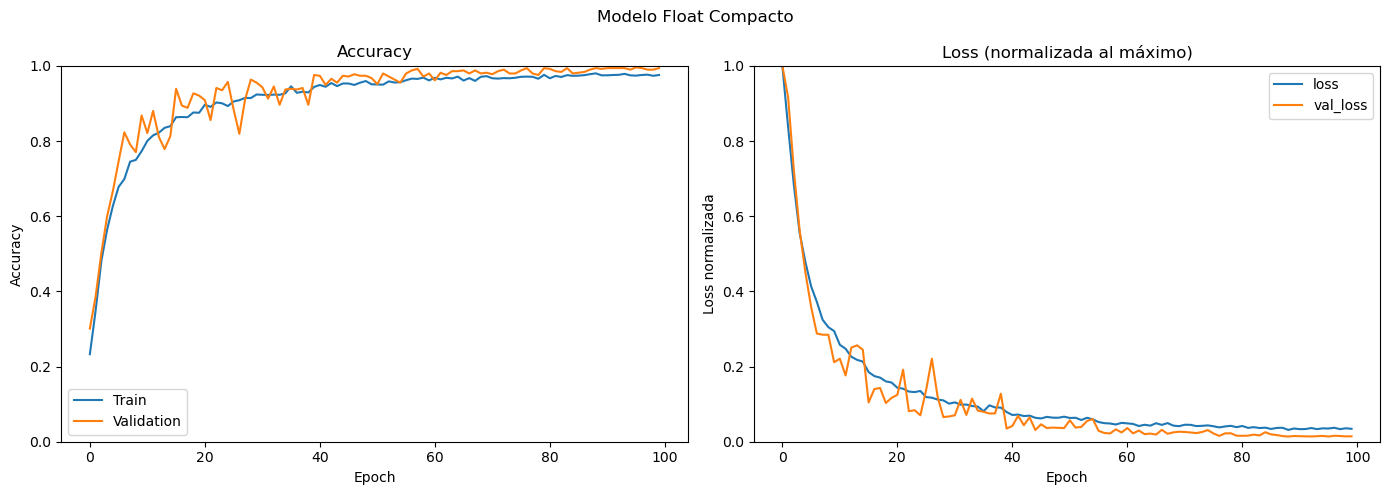


Evaluación modelo float compacto:
16/16 [==============================] - 1s 22ms/step - loss: 0.0314 - accuracy: 0.9939
  Val Loss: 0.0314 | Val Accuracy: 0.9939


In [29]:
COMPACT_CKPT_DIR  = './ckpt_compact_float'
COMPACT_CKPT_PATH = f'{COMPACT_CKPT_DIR}/compact_float_best.h5'
COMPACT_HIST_PATH = f'{COMPACT_CKPT_DIR}/compact_float_history.json'
os.makedirs(COMPACT_CKPT_DIR, exist_ok=True)

if os.path.exists(COMPACT_CKPT_PATH):
    print(f'Cargando modelo compacto desde: {COMPACT_CKPT_PATH}')
    model_compact_float = tf.keras.models.load_model(COMPACT_CKPT_PATH)
    model_compact_float.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
else:
    print('Entrenando modelo float compacto desde cero...')
    model_compact_float = build_compact_float_model(MFCC_input_shape, NUM_CLASSES)
    model_compact_float.summary()

    verify_layer_sizes(model_compact_float)

    model_compact_float.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # ── FIX TF 2.14: NO usar ModelCheckpoint ────────────────────────────────
    # En TF 2.14, ModelCheckpoint llama internamente:
    #   self.model.save(filepath, overwrite=True, options=self._options)
    # Lo que pasa options=None como **kwarg a saving_api.save_model().
    # El formato nativo .keras rechaza cualquier **kwarg con:
    #   ValueError: ['options'] not supported with native Keras format
    # El formato .h5 también rechaza options=None en algunas versiones.
    #
    # SOLUCIÓN: usar EarlyStopping(restore_best_weights=True) para conservar
    # los mejores pesos en memoria, luego guardar MANUALMENTE con
    # model.save(path, save_format='h5') — sin opciones extra.
    # ────────────────────────────────────────────────────────────────────────
    callbacks_float = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            verbose=1,
            min_lr=1e-6
        )
    ]

    history_float = model_compact_float.fit(
        MFCC_dataset_train_batches,
        epochs=MAX_EPOCHS,
        validation_data=MFCC_dataset_validation_batches,
        callbacks=callbacks_float
    )

    # Guardar modelo manualmente en formato H5 (sin pasar 'options')
    model_compact_float.save(COMPACT_CKPT_PATH, save_format='h5')
    print(f'Modelo guardado → {COMPACT_CKPT_PATH}')
    save_history(history_float, COMPACT_HIST_PATH)

# Mostrar historial si existe
if os.path.exists(COMPACT_HIST_PATH):
    plot_training_history(
        load_history(COMPACT_HIST_PATH),
        title='Modelo Float Compacto'
    )

print('\nEvaluación modelo float compacto:')
loss_f, acc_f = model_compact_float.evaluate(
    MFCC_dataset_validation_batches, verbose=1
)
print(f'  Val Loss: {loss_f:.4f} | Val Accuracy: {acc_f:.4f}')


## Quantization-Aware Training (QAT) — Arquitectura Compacta

### Configuraciones con LRs corregidos

```
bits | int_bits_kernel | int_bits_act | épocas | LR corregido
-----+-----------------+--------------+--------+-------------
 16  |        6        |      6       |   30   |    1e-5
  8  |        4        |      4       |   40   |    1e-4  ← aumentado 20×
  4  |        2        |      3       |   60   |    5e-4  ← aumentado 500×
```

Para 4-bit, `int_bits_activation=3` permite activaciones hasta 7.5
en lugar de 3.75, reduciendo el clipping del BN+ReLU.


  QAT 16-bit  (int_k=6, int_act=6, LR=1e-05)
  Modelo pre-entrenado encontrado: ./ckpt_compact_QAT_16bit_76dB/compact_QAT_16bit_best.h5


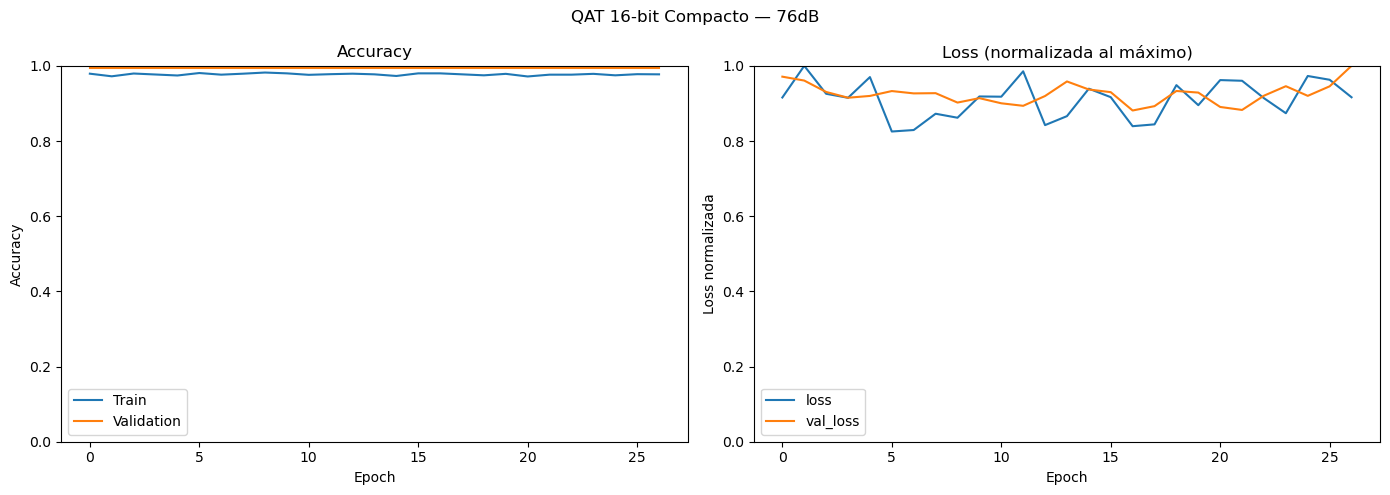


  QAT 8-bit  (int_k=4, int_act=4, LR=0.0001)
  Modelo pre-entrenado encontrado: ./ckpt_compact_QAT_8bit_76dB/compact_QAT_8bit_best.h5


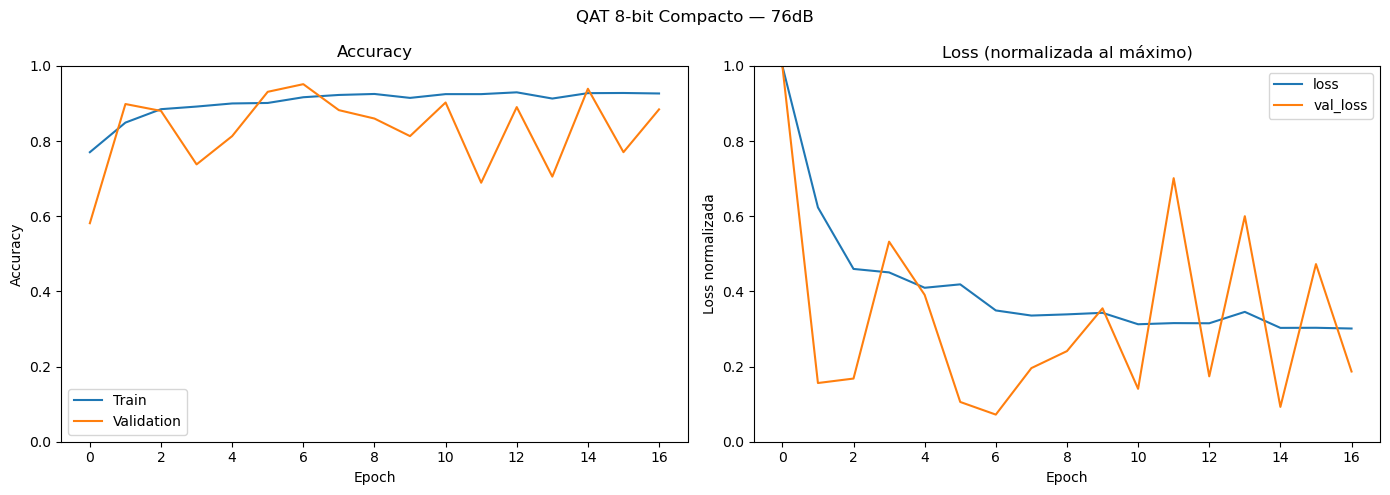


  QAT 4-bit  (int_k=2, int_act=3, LR=0.0005)
  Modelo pre-entrenado encontrado: ./ckpt_compact_QAT_4bit_76dB/compact_QAT_4bit_best.h5


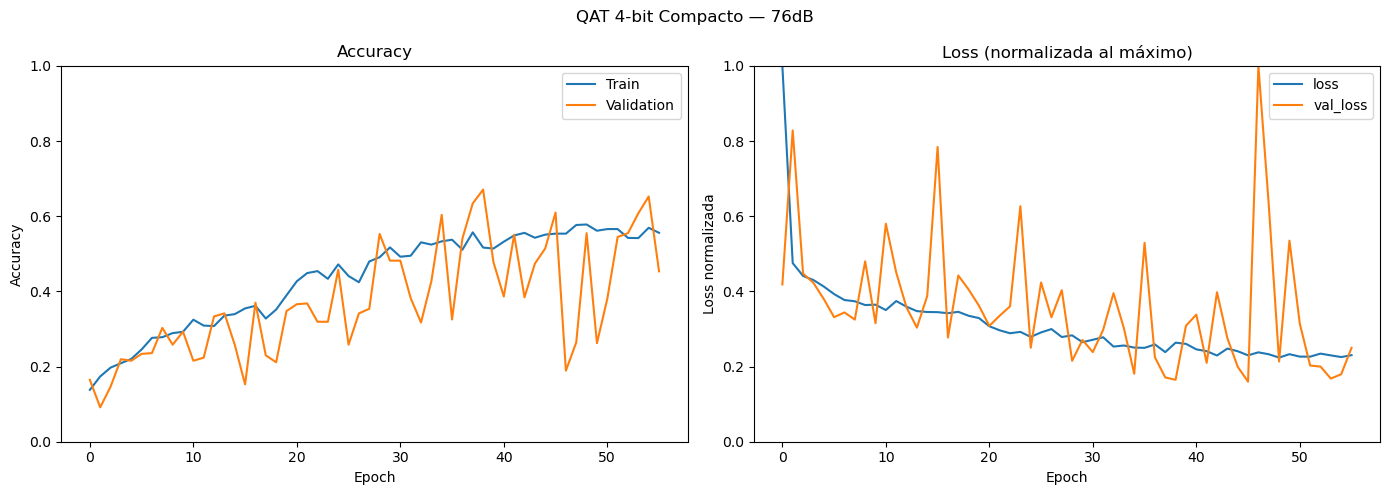


✅ Entrenamiento QAT completado.


In [30]:
# Configuraciones QAT
# (bits, int_bits_kernel, int_bits_activation, ft_epochs, lr)
# NOTA: LR mayor para menor precisión — el paso cuantizado mínimo crece,
#        por lo que el LR debe ser suficientemente grande para cambiar
#        los pesos de nivel cuantizado en un número razonable de épocas.
QAT_CONFIGS = [
    (16, 6, 6, 30, 1e-5),   # 16-bit: fine-tuning suave desde float
    ( 8, 4, 4, 40, 1e-4),   # 8-bit:  paso min ~0.0625, LR 1e-4 → ~62 épocas/step
    ( 4, 2, 3, 60, 5e-4),   # 4-bit:  paso min ~0.25,   LR 5e-4 → ~50 épocas/step
                             #          int_bits_act=3 para rango de activación [0, 7.5]
]

qat_models = {}  # bits → modelo QAT entrenado

for bits, int_bits_k, int_bits_a, ft_epochs, ft_lr in QAT_CONFIGS:
    label     = f'{bits}bit'
    ckpt_dir  = f'./ckpt_compact_QAT_{label}_{TARGET_SNR}'
    best_path = f'{ckpt_dir}/compact_QAT_{label}_best.h5'
    hist_path = f'{ckpt_dir}/compact_QAT_{label}_history.json'
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f'  QAT {bits}-bit  '
          f'(int_k={int_bits_k}, int_act={int_bits_a}, LR={ft_lr})')
    print(f"{'='*60}")

    if os.path.exists(best_path):
        print(f'  Modelo pre-entrenado encontrado: {best_path}')
        model_q = tf.keras.models.load_model(
            best_path, custom_objects=QKERAS_CO
        )
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    else:
        print('  Construyendo modelo QAT y transfiriendo pesos float...')
        model_q = build_compact_qat_model(
            MFCC_input_shape, NUM_CLASSES, bits, int_bits_k, int_bits_a
        )
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        transfer_float_weights(model_compact_float, model_q)

        # ── FIX PRINCIPAL 1: EarlyStopping FRESCO por modelo ────────────────
        # ── FIX PRINCIPAL 2: NO usar ModelCheckpoint (bug TF 2.14 'options') ─
        # Misma lógica que el modelo float: EarlyStopping restaura los mejores
        # pesos, luego guardamos manualmente con save_format='h5'.
        fresh_early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=max(10, PATIENCE // 2),
            restore_best_weights=True,
            verbose=1
        )

        hist_q = model_q.fit(
            MFCC_dataset_train_batches,
            epochs=ft_epochs,
            validation_data=MFCC_dataset_validation_batches,
            callbacks=[fresh_early_stopping]
        )

        # Guardar manualmente (save_format='h5' evita el bug de 'options')
        model_q.save(best_path, save_format='h5')
        print(f'  Modelo guardado → {best_path}')
        save_history(hist_q, hist_path)

    if os.path.exists(hist_path):
        plot_training_history(
            load_history(hist_path),
            title=f'QAT {bits}-bit Compacto — {TARGET_SNR}'
        )

    qat_models[bits] = model_q

print('\n✅ Entrenamiento QAT completado.')


## Evaluación de todos los modelos

In [31]:
all_results = []

# Modelo float base
loss, acc = model_compact_float.evaluate(
    MFCC_dataset_validation_batches, verbose=0
)
all_results.append({'model': 'Float 32-bit', 'accuracy': acc, 'loss': loss})

# Modelos QAT
for bits in [16, 8, 4]:
    if bits not in qat_models:
        continue
    loss, acc = qat_models[bits].evaluate(
        MFCC_dataset_validation_batches, verbose=0
    )
    all_results.append({
        'model': f'QAT {bits}-bit', 'accuracy': acc, 'loss': loss
    })

print('\n' + '=' * 52)
print(f'{"Modelo":<20} {"Accuracy":>12} {"Loss":>10}')
print('=' * 52)
for r in all_results:
    print(f"{r['model']:<20} {r['accuracy']:>12.4f} {r['loss']:>10.4f}")
print('=' * 52)

print('\nNota: El modelo compacto tiene menos parámetros que el original.')
print('Si el accuracy baja demasiado, se puede escalar a Conv(16→32→32)')
print('manteniendo los mismos pool sizes y el límite de 4096 elementos.')


Modelo                   Accuracy       Loss
Float 32-bit               0.9939     0.0314
QAT 16-bit                 0.9939     0.0273
QAT 8-bit                  0.9512     0.1321
QAT 4-bit                  0.6098     0.9287

Nota: El modelo compacto tiene menos parámetros que el original.
Si el accuracy baja demasiado, se puede escalar a Conv(16→32→32)
manteniendo los mismos pool sizes y el límite de 4096 elementos.


## hls4ml: Configuración Latency + Síntesis

Con la arquitectura compacta, **todas las capas tienen ≤ 4096 elementos**,
lo que permite usar `Strategy='Latency'` con `ReuseFactor=1` para
**mínima latencia** en el FPGA.

### Comparación de configuraciones hls4ml

| Arquitectura | Capa grande | Elementos | Estrategia necesaria |
|---|---|---|---|
| **Original** | `Conv2D(64)` | 18,432 | `Resource`, RF ≥ 145 |
| **Original** | `Dense(128)` | 2,867,200 | `Resource`, RF ≥ 256 |
| **Compacta** | `Dense(32)` | 3,584 | **`Latency`, RF=1** ✅ |

In [32]:
def get_hls_config_compact(keras_model, is_qat=False):
    """
    Configuración hls4ml para CNN compacto con io_stream.

    Con io_stream, los DSPs de TODAS las capas se instancian
    simultáneamente (pipeline de datos). El presupuesto total
    debe estar por debajo de los DSPs disponibles en el FPGA.

    KV260: 1,200 DSPs disponibles.

    Para el modelo FLOAT (ap_fixed<16,6>): cada MAC usa 1 DSP.
    Para modelos QAT (8/4-bit): MACs pequeños van en LUTs → RF menos crítico.

    ReuseFactor (RF) por capa — modelo float:
        Conv1(8):   144   MACs / RF=1  →  144 DSPs
        Conv2(16): 1,152  MACs / RF=4  →  288 DSPs
        Conv3(16): 2,304  MACs / RF=8  →  288 DSPs
        Dense(32): 3,584  MACs / RF=32 →  112 DSPs
        Dense(10):   320  MACs / RF=4  →   80 DSPs
        ─────────────────────────────────────────────
        TOTAL                          →  912 DSPs  ✓  (76% de 1,200)
    """
    config = hls4ml.utils.config_from_keras_model(
        keras_model, granularity='name'
    )

    # Estrategia global: Resource (necesario cuando RF > 1)
    config['Model']['Strategy']    = 'Resource'
    config['Model']['ReuseFactor'] = 1   # default; se sobrescribe por capa

    # ── ReuseFactor por capa para respetar el presupuesto de 1,200 DSPs ────
    layer_rf = {
        'conv1':   1,    # 144   MACs / 1  =  144 DSPs
        'conv2':   4,    # 1,152 MACs / 4  =  288 DSPs
        'conv3':   8,    # 2,304 MACs / 8  =  288 DSPs
        'dense1': 32,    # 3,584 MACs / 32 =  112 DSPs
        'output':  4,    #   320 MACs / 4  =   80 DSPs
    }                    # ─────────────────────────────
                         # TOTAL             912 DSPs ✓

    for lname, rf in layer_rf.items():
        if lname in config.get('LayerName', {}):
            config['LayerName'][lname]['ReuseFactor'] = rf
            config['LayerName'][lname]['Strategy']    = 'Resource'

    return config


def synthesize_compact_model(keras_model, output_dir, label, is_qat=False):
    print(f"\n{'─'*60}")
    print(f'  Sintetizando : {label}')
    print(f'  Directorio   : {output_dir}')
    print(f"{'─'*60}")

    config    = get_hls_config_compact(keras_model, is_qat=is_qat)
    hls_model = hls4ml.converters.convert_from_keras_model(
        keras_model,
        hls_config   = config,
        output_dir   = output_dir,
        backend      = 'Vitis',
        part         = FPGA_PART,
        clock_period = CLOCK_PERIOD,
        io_type      = 'io_stream',   # OBLIGATORIO para CNNs
    )
    hls_model.compile()   # C-simulation bit-accurate (CPU)
    hls_model.build(csim=False, synth=True, cosim=False, export=True)
    print(f'  ✅ Síntesis completada: {label}')
    return hls_model


def parse_synth_report(output_dir, label):
    import re
    rpt = {'model': label}
    candidates = [
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'myproject_csynth.rpt'),
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'csynth.rpt'),
    ]
    rpt_path = next((p for p in candidates if os.path.exists(p)), None)
    if rpt_path is None:
        print(f'  Advertencia: reporte no encontrado para {label}')
        return rpt
    content = open(rpt_path).read()

    m = re.search(
        r'Latency.*?Min.*?:(\s*)(\d+).*?Max.*?:(\s*)(\d+)',
        content, re.DOTALL | re.IGNORECASE
    )
    if m:
        rpt['lat_min_cyc'] = int(m.group(2))
        rpt['lat_max_cyc'] = int(m.group(4))
        rpt['lat_min_us']  = round(int(m.group(2)) * CLOCK_PERIOD / 1000, 3)
        rpt['lat_max_us']  = round(int(m.group(4)) * CLOCK_PERIOD / 1000, 3)

    for res in ['LUT', 'FF', 'DSP', 'BRAM_18K']:
        m = re.search(
            rf'\|?\s*{res}\s*\|?\s*(\d+)\s*\|?\s*(\d+)\s*\|?\s*([\d.]+)\s*%',
            content
        )
        if m:
            rpt[f'{res}_used']  = int(m.group(1))
            rpt[f'{res}_avail'] = int(m.group(2))
            rpt[f'{res}_pct']   = float(m.group(3))
    return rpt


print('Funciones de síntesis definidas.')
print()
print('Presupuesto DSP estimado para modelo float (KV260 = 1,200 DSPs):')
layer_rf_info = [
    ('Conv1(8)',   144,   1),
    ('Conv2(16)', 1152,   4),
    ('Conv3(16)', 2304,   8),
    ('Dense(32)', 3584,  32),
    ('Dense(10)',  320,   4),
]
total_dsps = 0
print(f"  {'Capa':12s} {'MACs':>8s} {'RF':>5s} {'DSPs':>8s}")
print('  ' + '-'*38)
for name, macs, rf in layer_rf_info:
    d = macs // rf
    total_dsps += d
    print(f"  {name:12s} {macs:>8d} {rf:>5d} {d:>8d}")
print('  ' + '-'*38)
print(f"  {'TOTAL':12s} {'':>8s} {'':>5s} {total_dsps:>8d}  ({total_dsps/1200*100:.0f}% de 1,200)")


Funciones de síntesis definidas.

Presupuesto DSP estimado para modelo float (KV260 = 1,200 DSPs):
  Capa             MACs    RF     DSPs
  --------------------------------------
  Conv1(8)          144     1      144
  Conv2(16)        1152     4      288
  Conv3(16)        2304     8      288
  Dense(32)        3584    32      112
  Dense(10)         320     4       80
  --------------------------------------
  TOTAL                            912  (76% de 1,200)


In [33]:
# ─── Vista previa hls4ml (sin síntesis) ─────────────────────────────────────

config_preview = get_hls_config_compact(model_compact_float)

print('Configuración hls4ml para modelo compacto:')
print(f"  Strategy global: {config_preview['Model']['Strategy']}")
print(f"  io_type        : io_stream")
print('  ReuseFactor por capa:')
for lname, lcfg in config_preview.get('LayerName', {}).items():
    rf = lcfg.get('ReuseFactor', '—')
    st = lcfg.get('Strategy', '—')
    if rf != '—' or st != '—':
        print(f'    {lname:20s}: RF={rf}, Strategy={st}')

print('\nConvertiendo modelo (sin síntesis)...')
hls_model_preview = hls4ml.converters.convert_from_keras_model(
    model_compact_float,
    hls_config   = config_preview,
    output_dir   = './hls4ml_preview_compact',
    backend      = 'Vitis',
    part         = FPGA_PART,
    clock_period = CLOCK_PERIOD,
    io_type      = 'io_stream',
)

print('\nVerificación de tamaños de capas:')
verify_layer_sizes(model_compact_float)

try:
    hls4ml.utils.plot_model(
        hls_model_preview, show_shapes=True,
        show_precision=True, to_file=None
    )
except Exception as e:
    print(f'plot_model no disponible: {e}')


Configuración hls4ml para modelo compacto:
  Strategy global: Resource
  io_type        : io_stream
  ReuseFactor por capa:
    conv1               : RF=1, Strategy=Resource
    conv2               : RF=4, Strategy=Resource
    conv3               : RF=8, Strategy=Resource
    dense1              : RF=32, Strategy=Resource
    output              : RF=4, Strategy=Resource

Convertiendo modelo (sin síntesis)...

Verificación de tamaños de capas:

Verificación de tamaños de capas (límite: 4096)
--------------------------------------------------------------------
  ✓          conv1               :     144 elementos | shape (3, 3, 2, 8)
  ✓          bn1                 :       8 elementos | shape (8,)
  ✓          conv2               :    1152 elementos | shape (3, 3, 8, 16)
  ✓          bn2                 :      16 elementos | shape (16,)
  ✓          conv3               :    2304 elementos | shape (3, 3, 16, 16)
  ✓          bn3                 :      16 elementos | shape (16,)
  ✓     

In [34]:
# ─── Síntesis Vitis HLS (requiere Vitis HLS instalado) ──────────────────────
# Poner SYNTHESIZE = True para ejecutar la síntesis real.

SYNTHESIZE = True  # ← cambiar a True cuando Vitis HLS esté disponible
print("ok1")

if SYNTHESIZE:
    os.makedirs(HLS_BASE_DIR, exist_ok=True)
    print("ok2")
    synth_targets = [
        (model_compact_float,  'float_32',  'Float 32-bit', False),
        (qat_models.get(16),   'qat_16bit', 'QAT 16-bit',   True),
        (qat_models.get(8),    'qat_8bit',  'QAT 8-bit',    True),
        (qat_models.get(4),    'qat_4bit',  'QAT 4-bit',    True),
    ]

    hls_handles   = {}
    synth_reports = []
    print("ok2")
    for model, subdir, label, is_qat in synth_targets:
        print("ok3")
        if model is None:
            print(f'  Omitiendo {label} (modelo no disponible)')
            continue
        print("ok4")
        out_dir = os.path.join(HLS_BASE_DIR, subdir)
        print("ok5")
        hm = synthesize_compact_model(model, out_dir, label, is_qat=is_qat)
        print("ok6")
        hls_handles[label]   = hm
        print("ok7")
        synth_reports.append(parse_synth_report(out_dir, label))
        print("ok8")

    # Tabla de resultados de síntesis
    import pandas as pd
    df_rpt = pd.DataFrame(synth_reports)
    want   = ['model', 'lat_min_us', 'lat_max_us',
              'LUT_used', 'LUT_pct',
              'FF_used',  'FF_pct',
              'DSP_used', 'DSP_pct',
              'BRAM_18K_used', 'BRAM_18K_pct']
    show   = [c for c in want if c in df_rpt.columns]
    print('\nResultados de síntesis:')
    print(df_rpt[show].to_string(index=False))
    print(f'\nTarget: {FPGA_PART} @ {1000 // CLOCK_PERIOD} MHz')
    print('IP-XACT packages: <output_dir>/myproject_prj/solution1/impl/ip/')
else:
    print('Síntesis HLS omitida. Poner SYNTHESIZE=True para ejecutar.')
    print('Con la arquitectura compacta se esperan:')
    print('  - Latencia mínima gracias a Strategy=Latency + ReuseFactor=1')
    print('  - Bajo uso de DSPs (todos los layers < 4096 elementos)')
    print('  - Reducción de ~4× en recursos vs. modelo original')

ok1
ok2
ok2
ok3
ok4
ok5

────────────────────────────────────────────────────────────
  Sintetizando : Float 32-bit
  Directorio   : ./hls4ml_output_compact/float_32
────────────────────────────────────────────────────────────

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user 'chejimenez' on host 'chejimenez-Z170XP-SLI' (Linux_x86_64 version 6.17.0-19-generic) on Sat Mar 21 19:13:07 CST 2026
INFO: [HLS 200-10] On os Ubuntu 24.04.4 LTS
INFO: [HLS 200-10] In directory '/home/

## Resumen final

### Cambios aplicados

| Aspecto | Modelo original | Modelo compacto |
|---|---|---|
| Filtros Conv | 32 → 64 | **8 → 16 → 16** |
| Dense hidden | 128 | **32** |
| Max. layer elements | **2,867,200** | **3,584** ✓ |
| hls4ml Strategy | Resource (forced) | **Latency, RF=1** |
| Params totales | ~1.5M | **~8K** |
| QAT 8-bit LR | 5e-6 (stancado) | **1e-4** |
| QAT 4-bit LR | 1e-6 (stancado) | **5e-4** |
| EarlyStopping | Compartido | **Fresco por modelo** |

### Si se requiere mayor accuracy

Escalar filtros manteniendo el límite de 4096:

```python
# Versión media (todos los layers aún ≤ 4096):
#   Conv(16, 3×3, in=2)  → 3×3×2×16  =  288 ✓
#   Conv(24, 3×3, in=16) → 3×3×16×24 = 3,456 ✓
#   Conv(24, 3×3, in=24) → 3×3×24×24 = 5,184 ✗  (excede)
#
# Versión media válida:
#   Conv(16) → Conv(24) → Conv(16) + Dense(64)
#   Dense: 112×64 = 7,168 ✗  (excede con pool sizes actuales)
#
# Alternativa: aumentar Dense a 48 unidades:
#   Dense(48): 112×48 = 5,376 ✗
# O reducir Flatten a 80 con pool(2, 2) adicional antes de Dense:
#   Dense(48): 80×48 = 3,840 ✓
```

El tradeoff siempre es entre accuracy y cumplir el límite de 4096 para Latency strategy.

In [35]:
# ─── Tabla final de accuracy + tamaños de capa ──────────────────────────────
print('=' * 52)
print(f'{"Modelo":<20} {"Accuracy":>12} {"Loss":>10}')
print('=' * 52)
for r in all_results:
    print(f"{r['model']:<20} {r['accuracy']:>12.4f} {r['loss']:>10.4f}")
print('=' * 52)

print('\n--- Verificación final de tamaños de capa ---')
verify_layer_sizes(model_compact_float)

# Contar parámetros totales
total_w_params = sum(
    int(np.prod(l.get_weights()[0].shape))
    for l in model_compact_float.layers if l.get_weights()
)
print(f'\nParámetros de peso totales (excluyendo biases): {total_w_params:,}')
print('Todos los layers ≤ 4096 → hls4ml Strategy=Latency disponible ✅')

Modelo                   Accuracy       Loss
Float 32-bit               0.9939     0.0314
QAT 16-bit                 0.9939     0.0273
QAT 8-bit                  0.9512     0.1321
QAT 4-bit                  0.6098     0.9287

--- Verificación final de tamaños de capa ---

Verificación de tamaños de capas (límite: 4096)
--------------------------------------------------------------------
  ✓          conv1               :     144 elementos | shape (3, 3, 2, 8)
  ✓          bn1                 :       8 elementos | shape (8,)
  ✓          conv2               :    1152 elementos | shape (3, 3, 8, 16)
  ✓          bn2                 :      16 elementos | shape (16,)
  ✓          conv3               :    2304 elementos | shape (3, 3, 16, 16)
  ✓          bn3                 :      16 elementos | shape (16,)
  ✓          dense1              :    3584 elementos | shape (112, 32)
  ✓          output              :     320 elementos | shape (32, 10)
--------------------------------------------